# Half-edge white/POC metric exploration

Scatterplots and Pearson correlation matrices for each `half_edge_lam_*_angle_*` column in `white_poc.csv`.

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [2]:
relative_csv = Path("outputs/tracts_in_cbsa_2020-2010-2000-1990-1980_years_march_2020_vintage/white_poc.csv")

for candidate_root in [Path.cwd(), *Path.cwd().parents]:
    csv_path = candidate_root / relative_csv
    if csv_path.exists():
        project_root = candidate_root
        break
else:
    raise FileNotFoundError(f"Could not find {relative_csv} from {Path.cwd()}")

df = pd.read_csv(csv_path)
df.shape

(1939, 43)

In [13]:
half_edge_pattern = re.compile(r"^half_edge_lam_(?P<lambda>.+)_angle_2") #?P<angle>\d+)$")
lambda_order = {"0": 0, "0_5": 0.5, "1": 1, "2": 2, "10": 10, "lim": float("inf")}
comparison_cols = ["dissimilarity", "moran"]

missing_cols = [column for column in comparison_cols if column not in df.columns]
if missing_cols:
    raise ValueError(f"Missing expected columns: {missing_cols}")

half_edge_cols = [column for column in df.columns if half_edge_pattern.match(column)]
print(half_edge_cols)
half_edge_cols = sorted(
    half_edge_cols,
    # key=lambda column: (
    #     lambda_order.get(half_edge_pattern.match(column).group("lambda"), 999),
    #     int(half_edge_pattern.match(column).group("angle")),
    # ),
)

if not half_edge_cols:
    raise ValueError("No half_edge_lam_*_angle_* columns found")

summary_rows = []
for column in half_edge_cols:
    match = half_edge_pattern.match(column)
    complete = df[[column, *comparison_cols]].dropna()
    summary_rows.append({
        "half_edge_column": column,
        "lambda": match.group("lambda").replace("_", "."),
        # "angle": int(match.group("angle")),
        "n": len(complete),
        "corr_with_dissimilarity": complete[column].corr(complete["dissimilarity"]),
        "corr_with_moran": complete[column].corr(complete["moran"]),
    })

summary = pd.DataFrame(summary_rows).sort_values("lambda")
summary

['half_edge_lam_0_angle_2', 'half_edge_lam_0_5_angle_2', 'half_edge_lam_1_angle_2', 'half_edge_lam_2_angle_2', 'half_edge_lam_10_angle_2', 'half_edge_lam_lim_angle_2']


,half_edge_column,lambda,n,corr_with_dissimilarity,corr_with_moran
1,half_edge_lam_0_angle_2,0,1939,0.763640,0.723075
0,half_edge_lam_0_5_angle_2,0.5,1939,0.792990,0.701024
3,half_edge_lam_1_angle_2,1,1939,0.812593,0.682970
2,half_edge_lam_10_angle_2,10,1939,0.877505,0.577560
4,half_edge_lam_2_angle_2,2,1939,0.836578,0.655396
5,half_edge_lam_lim_angle_2,lim,1939,0.889772,0.524328


- with 0 lambda capy is closer to Moran + further away from dissimilarity
- and with higher lambda capy is closer to dissimilarity + further away from Moran

Dominating within-edges makes capy similar to dissimilarity.
Dominating between-edges makes capy similar to Moran.

The default lambda=1 is already close to the within-based end. but why???

Each figure below uses one half-edge metric column. The left and middle panels are the requested scatterplots; the right panel is the Pearson correlation matrix for `half_edge`, `dissimilarity`, and `moran`.

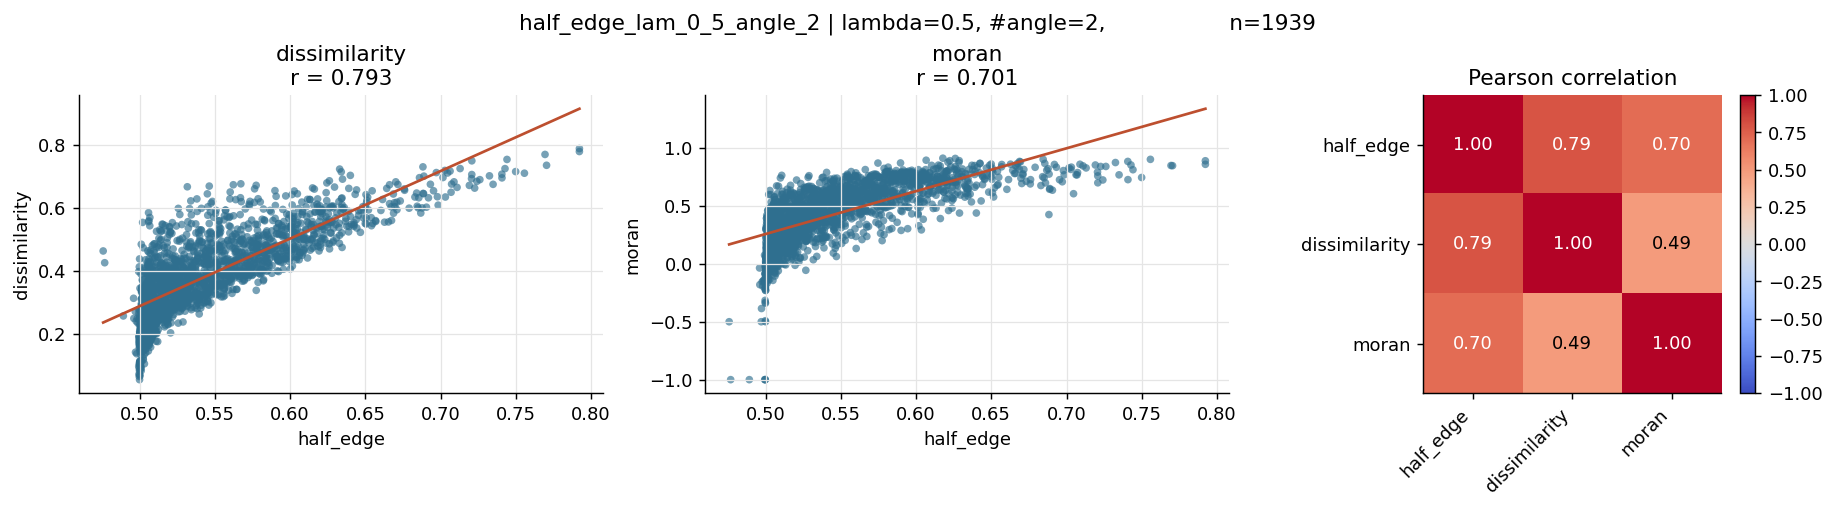

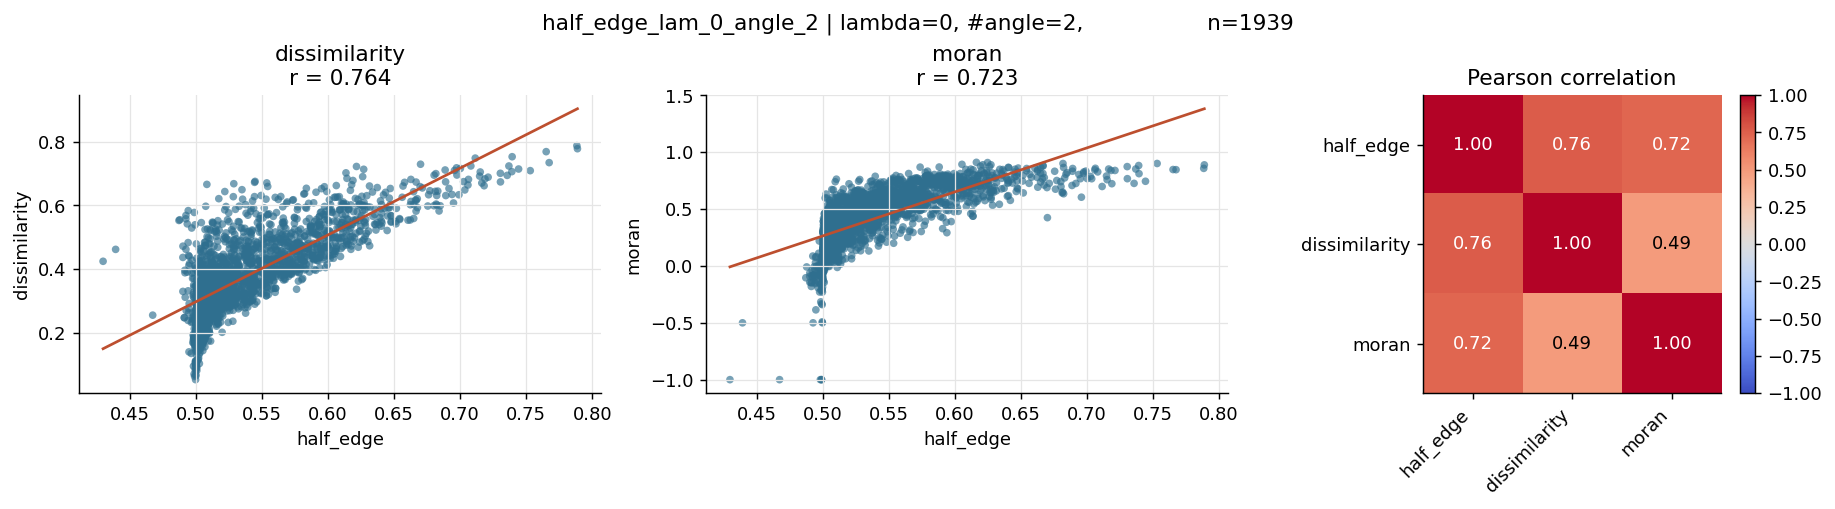

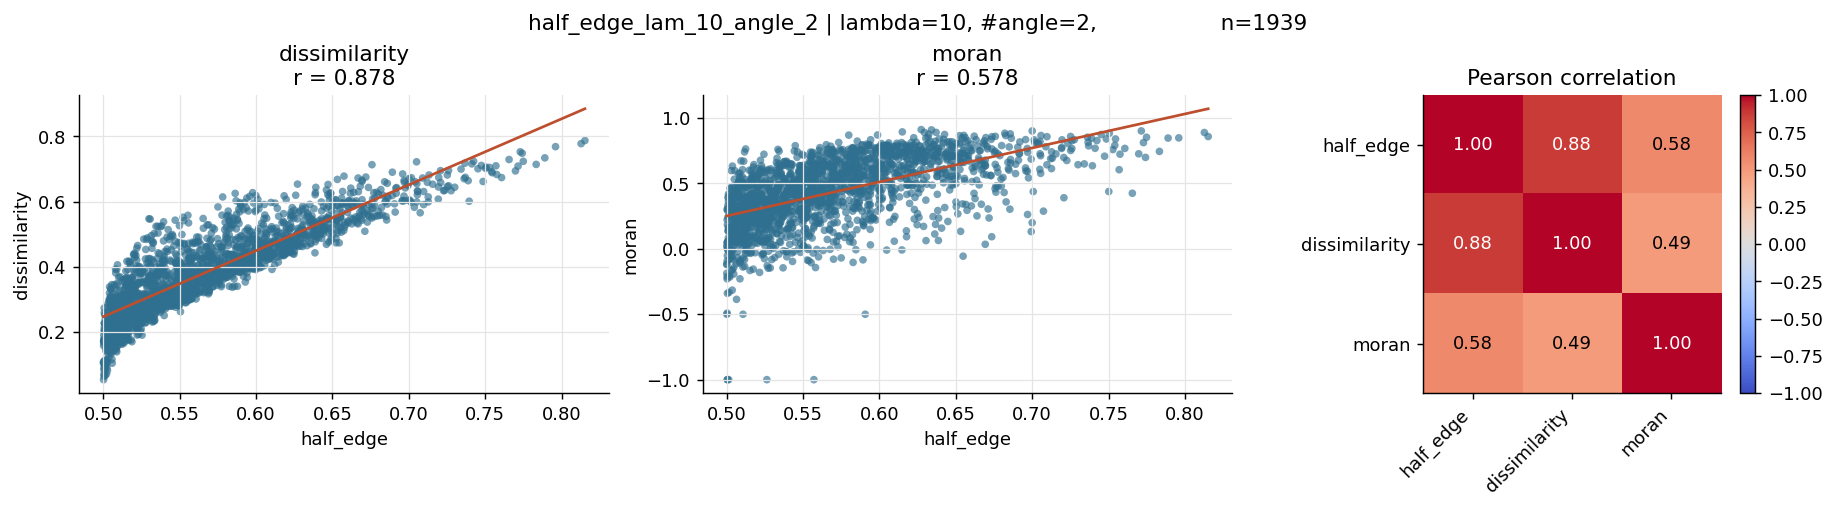

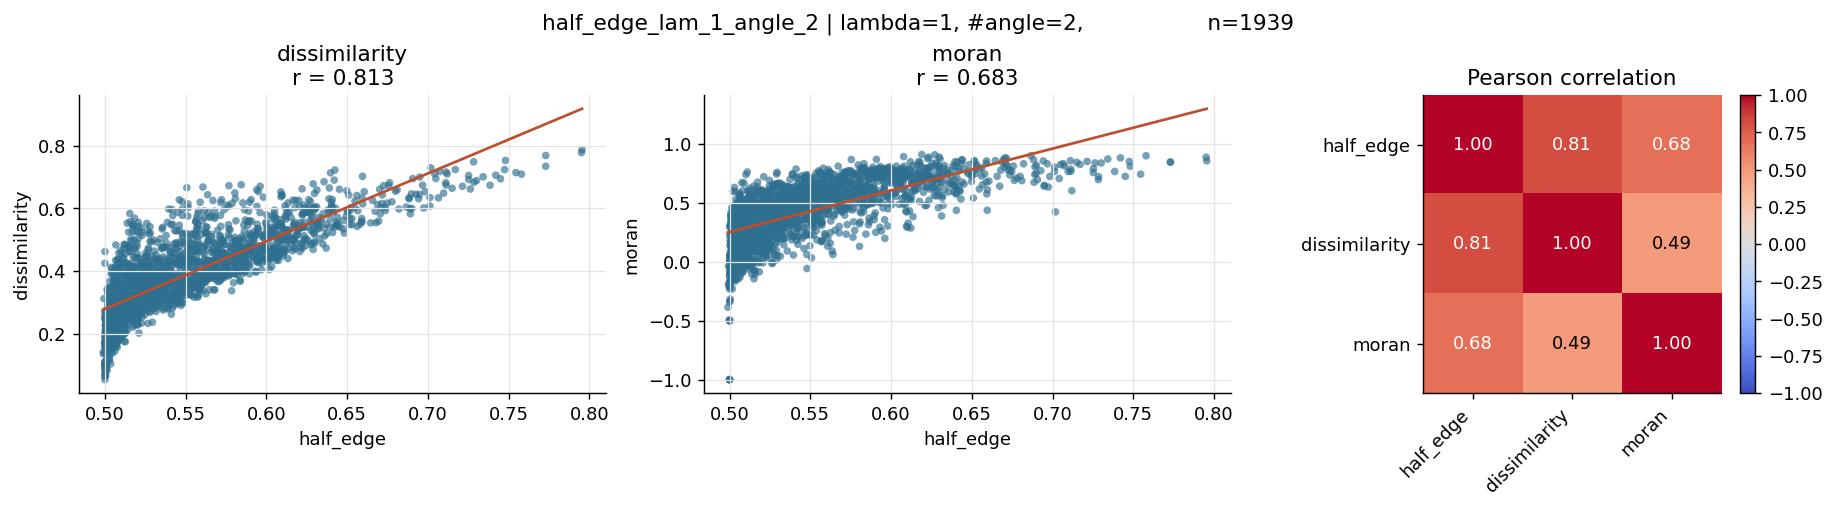

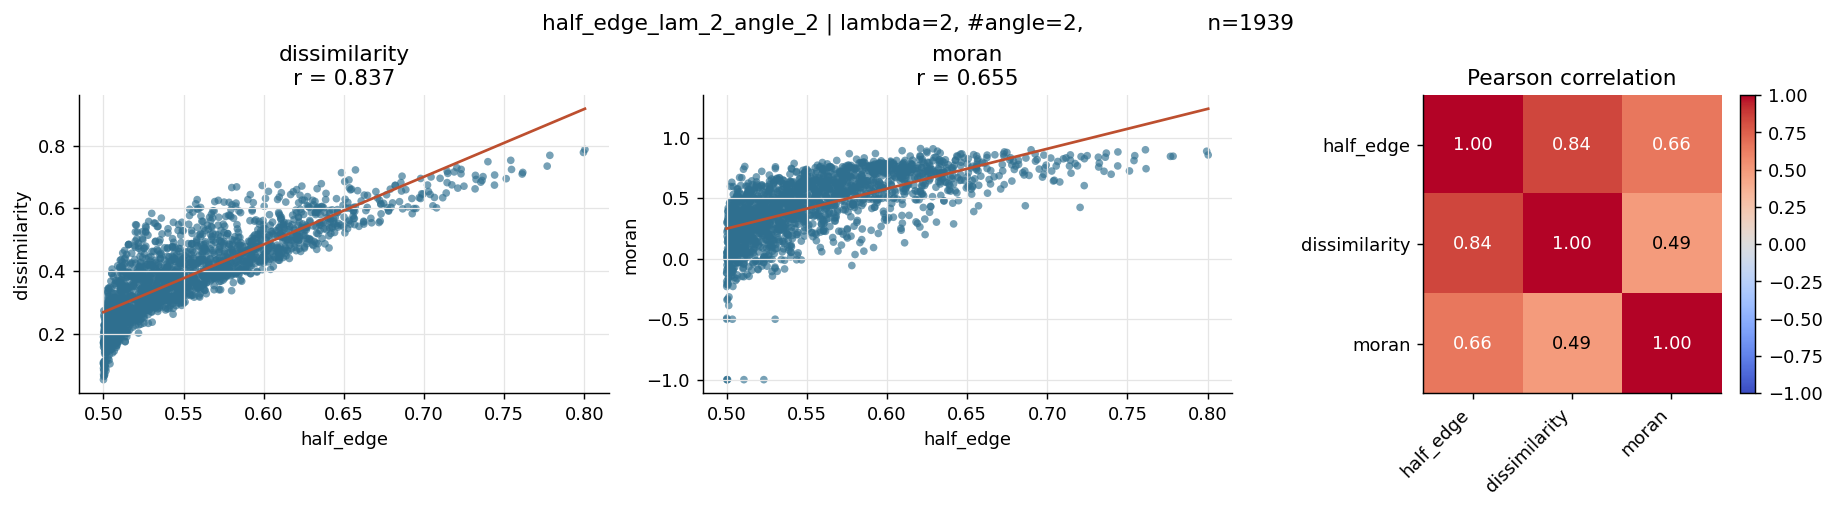

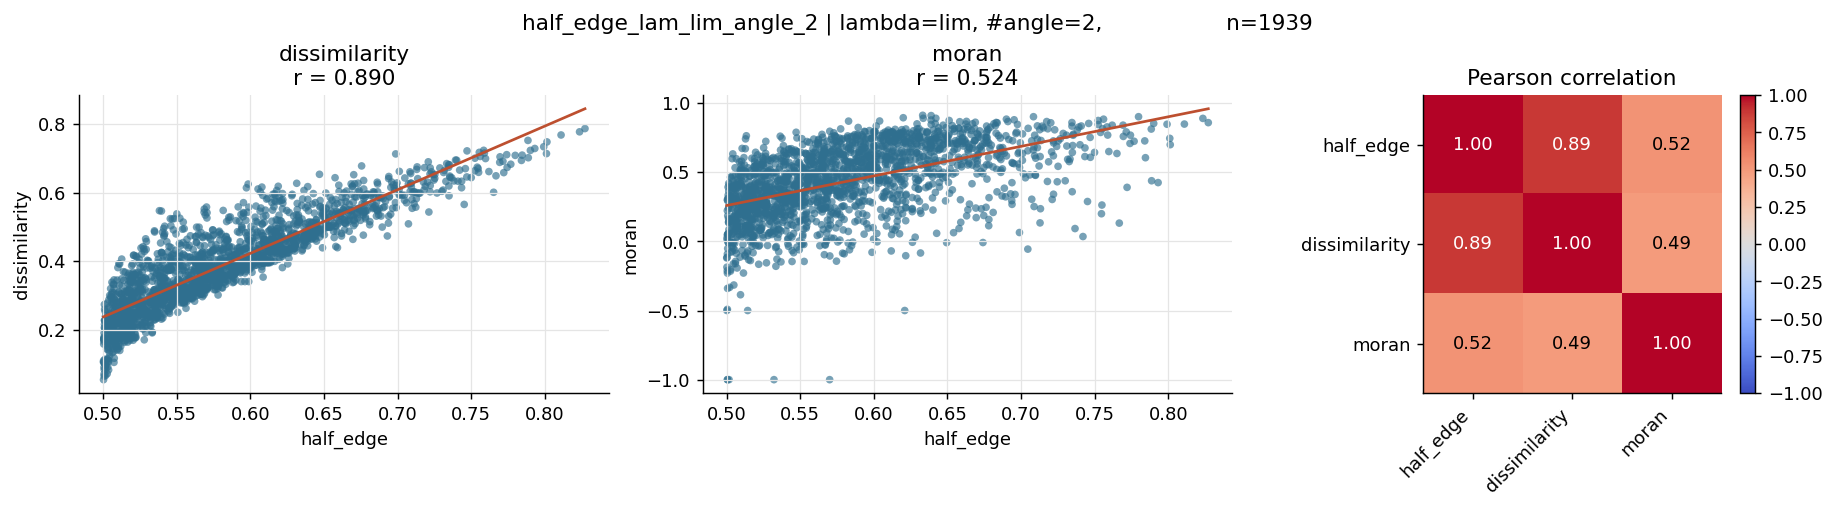

In [16]:
scatter_color = "#2f6f8f"
fit_color = "#bd4f2f"

for column in half_edge_cols:
    match = half_edge_pattern.match(column)
    lambda_label = match.group("lambda").replace("_", ".")
    # angle_label = match.group("angle")
    plot_data = df[[column, *comparison_cols]].dropna()
    corr = plot_data.rename(columns={column: "half_edge"})[["half_edge", *comparison_cols]].corr()

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(14, 3.8),
        gridspec_kw={"width_ratios": [1, 1, 0.9]},
        constrained_layout=True,
    )

    for ax, comparison_col in zip(axes[:2], comparison_cols):
        x = plot_data[column]
        y = plot_data[comparison_col]
        ax.scatter(x, y, s=18, alpha=0.65, color=scatter_color, edgecolors="none")

        if len(plot_data) > 1 and x.nunique() > 1:
            slope, intercept = np.polyfit(x, y, 1)
            xs = np.linspace(x.min(), x.max(), 100)
            ax.plot(xs, slope * xs + intercept, color=fit_color, linewidth=1.5)

        ax.set_xlabel("half_edge")
        ax.set_ylabel(comparison_col)
        ax.set_title(f"{comparison_col}\nr = {corr.loc['half_edge', comparison_col]:.3f}")
        ax.grid(True, color="#e5e5e5", linewidth=0.7)

    ax = axes[2]
    matrix = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(corr.index)), corr.index)
    ax.set_title("Pearson correlation")

    for row_index in range(len(corr.index)):
        for col_index in range(len(corr.columns)):
            value = corr.iloc[row_index, col_index]
            text_color = "white" if abs(value) > 0.65 else "black"
            ax.text(col_index, row_index, f"{value:.2f}", ha="center", va="center", color=text_color)

    fig.colorbar(matrix, ax=ax, fraction=0.046, pad=0.04)
    fig.suptitle(f"{column} | lambda={lambda_label}, #angle={angle_label}, \
                 n={len(plot_data)}", fontsize=12)
    plt.show()

A compact summary of the two requested correlations across all half-edge columns:

In [5]:
summary

,half_edge_column,lambda,angle,n,corr_with_dissimilarity,corr_with_moran
0,half_edge_lam_0_angle_1,0,1,1939,0.763640,0.723075
1,half_edge_lam_0_angle_2,0,2,1939,0.763640,0.723075
2,half_edge_lam_0_5_angle_1,0.5,1,1939,0.792981,0.701024
3,half_edge_lam_0_5_angle_2,0.5,2,1939,0.792990,0.701024
4,half_edge_lam_1_angle_1,1,1,1939,0.812574,0.682973
5,half_edge_lam_1_angle_2,1,2,1939,0.812593,0.682970
6,half_edge_lam_2_angle_1,2,1,1939,0.836539,0.655405
7,half_edge_lam_2_angle_2,2,2,1939,0.836578,0.655396
8,half_edge_lam_10_angle_1,10,1,1939,0.877394,0.577600
9,half_edge_lam_10_angle_2,10,2,1939,0.877505,0.577560
